In [1]:
import emcee
import numpy as np
import matplotlib.pyplot as plt


In [2]:

filename = "SigOriData/SO1152_12CO_posteriors.h5"  # your emcee output file
reader = emcee.backends.HDFBackend(filename, read_only=True)

In [12]:

# Basic info
nsteps, nwalkers, ndim = reader.get_chain().shape
print(f"nsteps={nsteps}, nwalkers={nwalkers}, ndim={ndim}")
burnin = nsteps // 3
thin = 1

nsteps=100, nwalkers=75, ndim=15


In [13]:
ndim

15

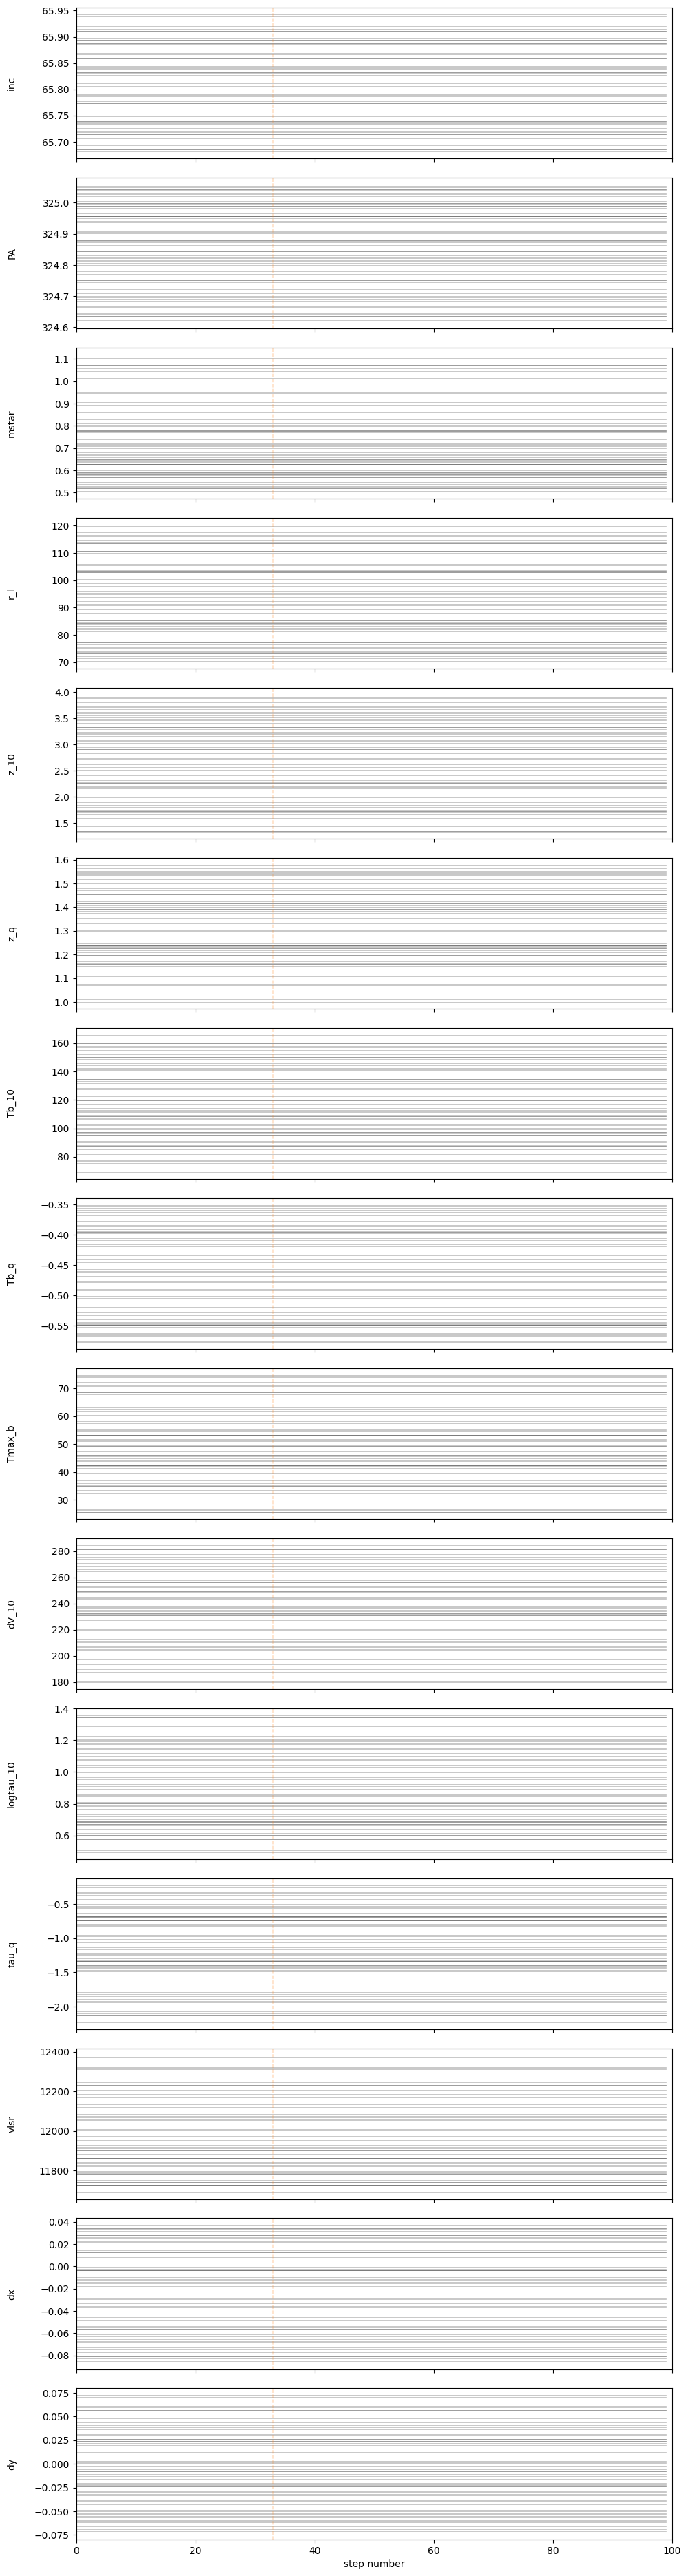

In [14]:
labels = ["inc", "PA", "mstar", "r_l", "z_10", "z_q", 
          "Tb_10", "Tb_q", "Tmax_b", "dV_10", "logtau_10",
          "tau_q", "vlsr", "dx", "dy"] 

chain = reader.get_chain()  # shape (nsteps, nwalkers, ndim)

fig, axes = plt.subplots(ndim, figsize=(10, 2.5 * ndim), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(chain[:, :, i], "k", alpha=0.3, lw=0.5)
    ax.set_xlim(0, nsteps)
    ax.set_ylabel(labels[i])
    ax.axvline(burnin, color="C1", ls="--", lw=1)  # mark burn-in
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("step number")
plt.tight_layout()
plt.savefig("walkers.png", dpi=150)

(5025, 15)


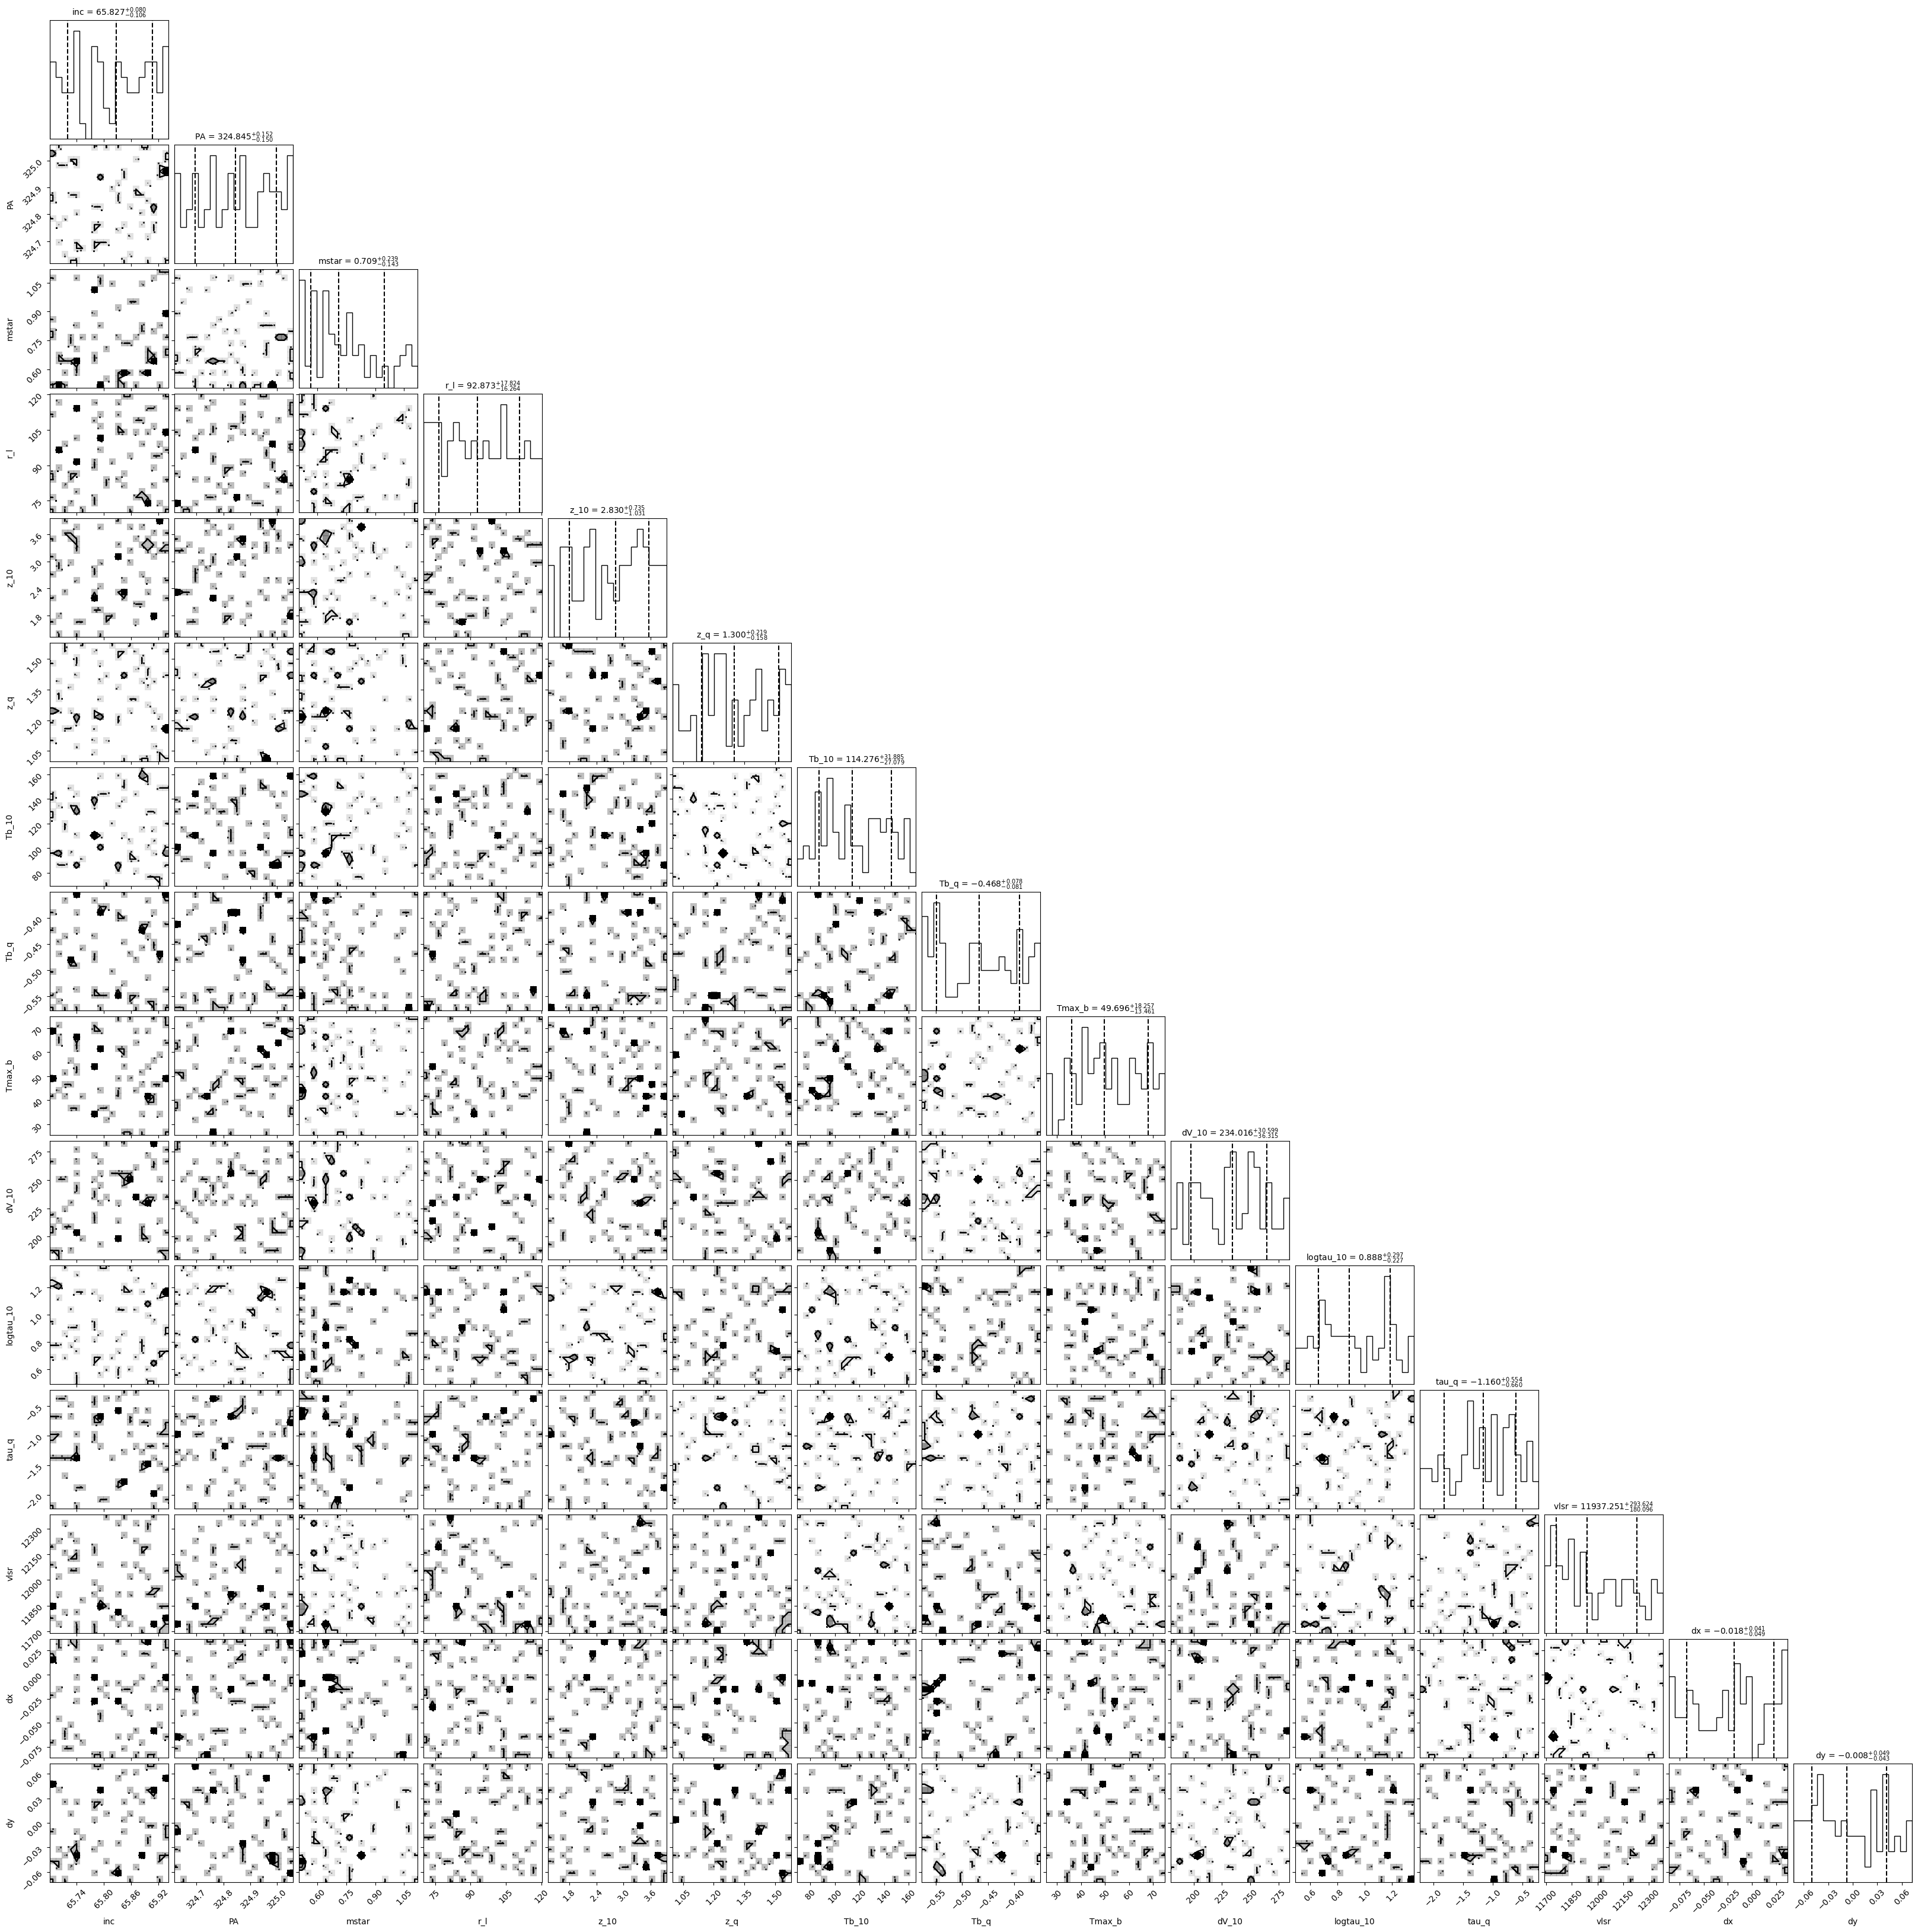

In [15]:
import corner

flat_samples = reader.get_chain(discard=burnin, thin=thin, flat=True)
log_prob = reader.get_log_prob(discard=burnin, thin=thin, flat=True)  # optional

print(flat_samples.shape)  # (n_samples, ndim)

fig = corner.corner(
    flat_samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    title_kwargs={"fontsize": 10},
)
fig.savefig("corner.png", dpi=150)